# Introduction
Markdown and inline comments guide technical stakeholders through executing code with a summary of rationale and outcomes provided in the report.

Execute the code in all cells in the order they appear below:

### Packages & libraries

In [1]:
# Run this to avoid the following warning during the K-Means Clustering section
# "UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads."

import os
os.environ['OMP_NUM_THREADS'] = '8'

In [2]:
# Import all libraries required for Turtle Games loyalty analysis

# Data wrangling and numeric operations
import pandas as pd
import numpy as np

# Machine learning and modeling
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import silhouette_score

# Natural Language Processing
import nltk
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import Counter

# Visualization and plot styling
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
import scipy.stats as stats

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

### Functions
All functions used for this project

In [3]:
# Scatter plot used in Simple Linear Regression
def plot_loyalty_regression(x_values, model, x_label, filename):
    plt.scatter(x_values, y_loyalty, color='blue')
    plt.plot(x_values, model.predict(x_values), color='red', label='Regression line')
    plt.xlabel(x_label)
    plt.ylabel('Loyalty')
    plt.title(f'Regression: Loyalty vs {x_label}')
    plt.legend()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [4]:
# Wordcloud visualisations in NLP section
def generate_wordcloud(text, colormap, filename):
    wordcloud = WordCloud(width=1600,
                          height=900,
                          background_color='white',
                          colormap=colormap,
                          min_font_size=10).generate(text)
    
    plt.figure(figsize=(16, 9))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.tight_layout(pad=0)
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [111]:
# Histogram of compound sentiment scores
def plot_sentiment_histogram(series, title, color, filename):
    plt.figure(figsize=(8, 5))
    plt.hist(series, bins=15, edgecolor='black', alpha=0.7, color=color)
    plt.title(title)
    plt.xlabel('Compound Score')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

### Data Ingestion
First import the csv created by the previous activities in R where it was cleaned and validated. File named "turtle_ready_for_regression.csv"

In [5]:
# Create the initial dataframe from the csv described above
regression_1 = pd.read_csv('turtle_ready_for_regression.csv')

### Data validation

In [6]:
# Inspect the dataframe to ensure it has been created from the correct file
regression_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   gender     2000 non-null   object 
 1   age        2000 non-null   int64  
 2   income     2000 non-null   float64
 3   spending   2000 non-null   int64  
 4   loyalty    2000 non-null   int64  
 5   education  2000 non-null   object 
 6   language   2000 non-null   object 
 7   platform   2000 non-null   object 
 8   product    2000 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB


Confirms 2,000 customer records with 9 variables from R cleaning phase. All columns show 2,000 non-null values, indicating complete data. Structure includes demographic (gender, age, education), behavioral (spending, loyalty), and transactional (income, product) variables with appropriate data types.

# Simple Linear Regression - All Customers

### Spending vs loyalty

In [7]:
# Define independent variable.
x_spending = regression_1['spending'].values.reshape(-1, 1)

# Define dependent variable.
y_loyalty = regression_1['loyalty'].values.reshape(-1, 1)

# Create model and print summary of metrics.
lm_spending = LinearRegression()
lm_spending.fit(x_spending, y_loyalty)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# Extract the estimated parameters.
print("Estimated parameters:")
print(f"Intercept: {lm_spending.intercept_[0]}")
print(f"Coefficient: {lm_spending.coef_[0][0]}")

# Extract the standard errors.
print("\nNote: Standard errors not available in sklearn - use statsmodels for statistical significance")

# Extract the predicted values.
y_pred_spending = lm_spending.predict(x_spending)
print(f"\nPredicted values (first 10):")
print(y_pred_spending[:10].flatten())

Estimated parameters:
Intercept: -75.05266293364707
Coefficient: 33.06169325867294

Note: Standard errors not available in sklearn - use statsmodels for statistical significance

Predicted values (first 10):
[1214.35337415 2602.94449102  123.31749662 2470.69771798 1247.41506741
 2437.63602473  123.31749662 3032.74650338   24.13241684 2305.38925169]


In [9]:
# Set the X coefficient and the constant to generate the regression table.
intercept = lm_spending.intercept_[0]
coefficient = lm_spending.coef_[0][0]

regression_table_spending = pd.DataFrame({
    'Variable': ['Intercept', 'Spending'],
    'Coefficient': [intercept, coefficient]
})

# View the output.
print(regression_table_spending)

    Variable  Coefficient
0  Intercept   -75.052663
1   Spending    33.061693


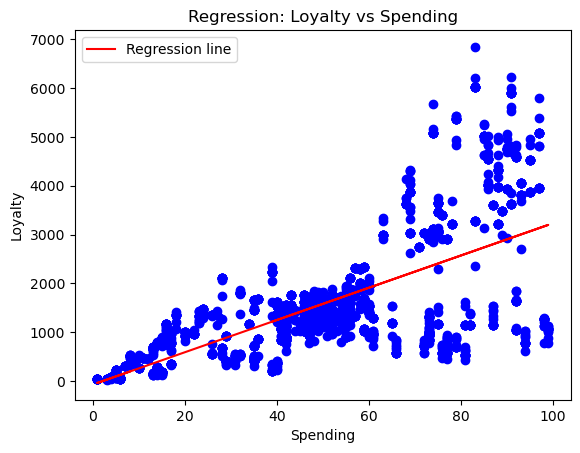

In [10]:
# Plot the graph with a regression line.
plot_loyalty_regression(x_spending, lm_spending, 'Spending', 'spending_plot.png')

### Income vs Loyalty

In [11]:
# Define independent variable.
x_income = regression_1['income'].values.reshape(-1, 1)

# Define dependent variable.
y_loyalty = regression_1['loyalty'].values.reshape(-1, 1)

# Create model and print summary of metrics.
lm_income = LinearRegression()
lm_income.fit(x_income, y_loyalty)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# Extract the estimated parameters.
print("Estimated parameters:")
print(f"Intercept: {lm_income.intercept_[0]}")
print(f"Coefficient: {lm_income.coef_[0][0]}")

# Extract the standard errors.
print("\nNote: Standard errors not available in sklearn - use statsmodels for statistical significance")

# Extract the predicted values.
y_pred_income = lm_income.predict(x_income)
print(f"\nPredicted values (first 10):")
print(y_pred_income[:10].flatten())

Estimated parameters:
Intercept: -65.68651279500432
Coefficient: 34.1878254856689

Note: Standard errors not available in sklearn - use statsmodels for statistical significance

Predicted values (first 10):
[354.82374068 354.82374068 382.85775758 382.85775758 410.89177448
 410.89177448 438.92579137 438.92579137 466.95980827 466.95980827]


In [13]:
# Set the the X coefficient and the constant to generate the regression table.
intercept = lm_income.intercept_[0]
coefficient = lm_income.coef_[0][0]

regression_table_income = pd.DataFrame({
    'Variable': ['Intercept', 'Income'],
    'Coefficient': [intercept, coefficient]
})

# View the output.
print(regression_table_income)

    Variable  Coefficient
0  Intercept   -65.686513
1     Income    34.187825


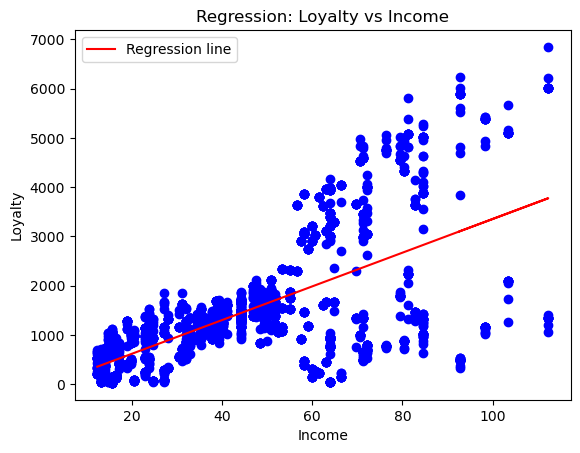

In [14]:
# Plot the graph with a regression line.
plot_loyalty_regression(x_income, lm_income, 'Income', 'income_plot.png')

### Age vs Loyalty

In [15]:
# Define independent variable.
x_age = regression_1['age'].values.reshape(-1, 1)

# Define dependent variable.
y_loyalty = regression_1['loyalty'].values.reshape(-1, 1)

# Create model and print summary of metrics.
lm_age = LinearRegression()
lm_age.fit(x_age, y_loyalty)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
# Extract the estimated parameters.
print("Estimated parameters:")
print(f"Intercept: {lm_age.intercept_[0]}")
print(f"Coefficient: {lm_age.coef_[0][0]}")

# Extract the standard errors.
print("\nNote: Standard errors not available in sklearn - use statsmodels for statistical significance")

# CORRECTION: Use x_age to get predictions from the lm_age model
y_pred_age = lm_age.predict(x_age)
print(f"\nPredicted values (first 10):")
print(y_pred_age[:10].flatten())

Estimated parameters:
Intercept: 1736.517739399063
Coefficient: -4.012805149995269

Note: Standard errors not available in sklearn - use statsmodels for statistical significance

Predicted values (first 10):
[1664.2872467  1644.22322095 1648.2360261  1636.19761065 1604.09516945
 1640.2104158  1588.04394885 1636.19761065 1471.6725995  1608.1079746 ]


In [17]:
# Set the the X coefficient and the constant to generate the regression table.
intercept = lm_age.intercept_[0]
coefficient = lm_age.coef_[0][0]

regression_table_age = pd.DataFrame({
    'Variable': ['Intercept', 'Age'],
    'Coefficient': [intercept, coefficient]
})

# View the output.
print(regression_table_age)

    Variable  Coefficient
0  Intercept  1736.517739
1        Age    -4.012805


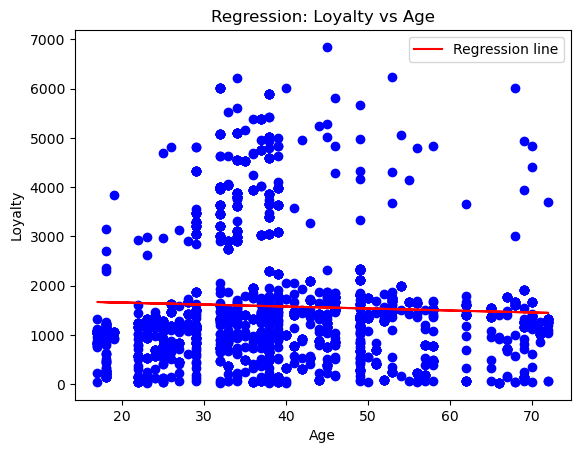

In [18]:
# Plot the graph with a regression line.
plot_loyalty_regression(x_age, lm_age, 'Age', 'age_plot.png')

### Simple Linear Regression Statistics

In [19]:
# Compare all three models
print("MODEL COMPARISON:")
print("="*50)
print("Spending vs Loyalty:")
print(f"  Coefficient: {lm_spending.coef_[0][0]:.2f}")
print(f"  R-squared (approx): {lm_spending.score(x_spending, y_loyalty):.3f}")

print("\nIncome vs Loyalty:")
print(f"  Coefficient: {lm_income.coef_[0][0]:.2f}") 
print(f"  R-squared (approx): {lm_income.score(x_income, y_loyalty):.3f}")

print("\nAge vs Loyalty:")
print(f"  Coefficient: {lm_age.coef_[0][0]:.2f}")
print(f"  R-squared (approx): {lm_age.score(x_age, y_loyalty):.3f}")

MODEL COMPARISON:
Spending vs Loyalty:
  Coefficient: 33.06
  R-squared (approx): 0.452

Income vs Loyalty:
  Coefficient: 34.19
  R-squared (approx): 0.380

Age vs Loyalty:
  Coefficient: -4.01
  R-squared (approx): 0.002


### Key findings
Spending is the strongest single predictor of loyalty (R² = 0.452).
£1 spent yields approx 33 loyalty points

Income is a moderately strong predictor (R² = 0.380).
Every £1000 increase in salary increase loyalty approx 34 points

Age is not a meaningful predictor (R² = 0.002).
Coefficient for age not helpful for this study

At this point the models we have built are not accurate enough for Turtle Games to confidently predict loyalty among its customers and use in their strategy. At best, the "Loyalty vs Spending" model explains only 45% of loyalty point accumulation by customers and other models are weaker. As stated, "Age vs Loyalty" is completely meaningless. To attempt to increase accuracy, next we will use k-means clustering to look for distinct customer segments. We can then repeat the simple linear regression exercise against high value customer segments that we identify for more accurate modelling. 

# K-Means Clustering. Identify distinct customer groups

In [20]:
# Create df for segmentation
cluster_master = regression_1.copy()

In [21]:
cluster_master.head()

,gender,age,income,spending,loyalty,education,language,platform,product
0,Male,18,12.30,39,210,graduate,EN,Web,453
1,Male,23,12.30,81,524,graduate,EN,Web,466
2,Female,22,13.12,6,40,graduate,EN,Web,254
3,Female,25,13.12,77,562,graduate,EN,Web,263
4,Female,33,13.94,40,366,graduate,EN,Web,291


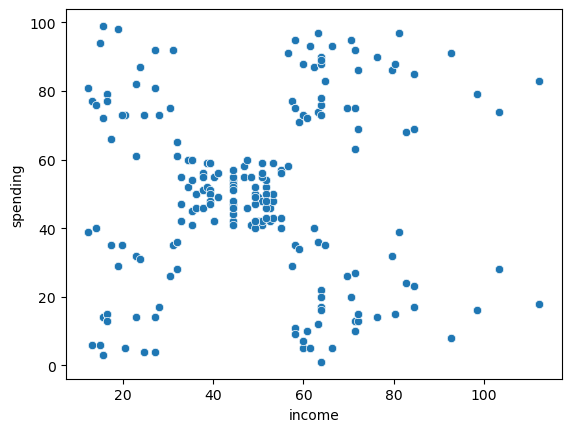

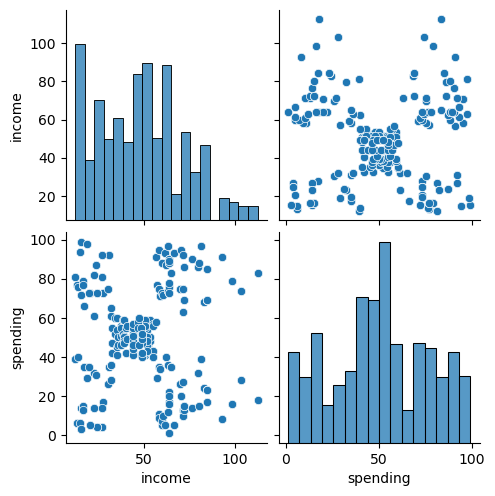

In [22]:
# Create a scatterplot with Seaborn and export as png
scatter = sns.scatterplot(x='income',
                          y='spending',
                          data=cluster_master)
scatter.figure.savefig('scatterplot_income_spending.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a pairplot with Seaborn and export as png
x = cluster_master[['income', 'spending']]
pairplot = sns.pairplot(cluster_master,
                         vars=x)
pairplot.savefig('pairplot_income_spending.png', dpi=300)

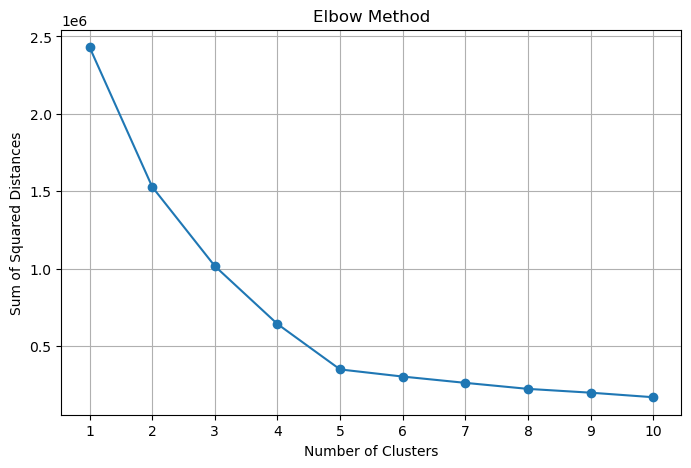

In [23]:
# Use only the columns you're interested in
x = cluster_master[['income', 'spending']]

# Elbow method code
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x)
    ss.append(kmeans.inertia_)

# Plot it
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), ss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Sum of Squared Distances")
plt.grid(True)
plt.xticks(range(1, 11))
plt.savefig('elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

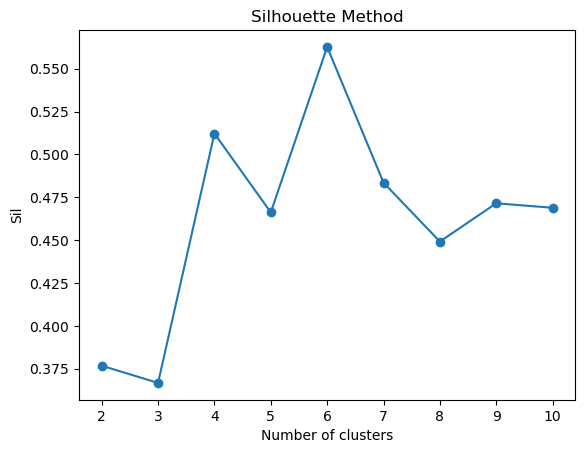

In [24]:
# Define x with your specific columns from reviews_mod
x = cluster_master[['income', 'spending']]

# Find the range of clusters to be used using silhouette method.
sil = []
kmax = 10

for k in range(2, kmax+1):
    kmeans_s = KMeans(n_clusters = k).fit(x)
    labels = kmeans_s.labels_
    sil.append(silhouette_score(x,
                                labels,
                                metric = 'euclidean'))

# Plot the silhouette method.
plt.plot(range(2, kmax+1),
         sil,
         marker='o')

plt.title("Silhouette Method")
plt.xlabel("Number of clusters")
plt.ylabel("Sil")
plt.xticks(range(2, kmax+1))
plt.savefig('silhouette_method.png', dpi=300, bbox_inches='tight')
plt.show()

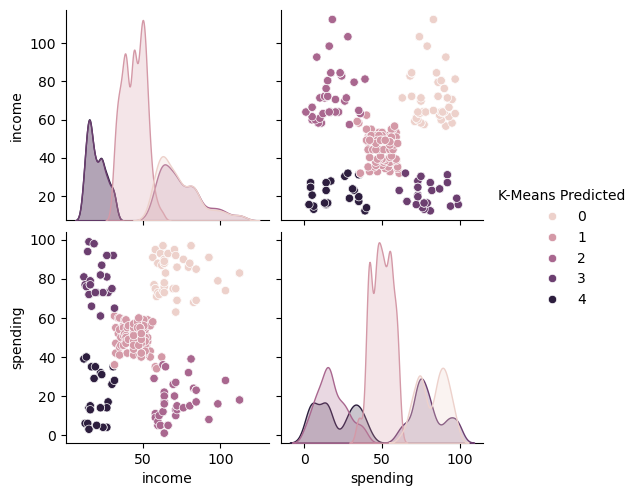

In [25]:
# First, define x with a copy of your current data frame and columns
x = cluster_master[['income', 'spending']].copy()  # Use 'regression_1' and .copy()

# Then fit k-means with 5 clusters:
kmeans = KMeans(n_clusters=5,
                max_iter=15000,
                init='k-means++',
                random_state=42).fit(x)

# Get the cluster labels
clusters = kmeans.labels_
x['K-Means Predicted'] = clusters

# Optional: Add labels back to your main DataFrame for later analysis
cluster_master['cluster'] = clusters

# Plot the clusters (this will work without warning now)
sns.pairplot(x, hue='K-Means Predicted', diag_kind='kde')

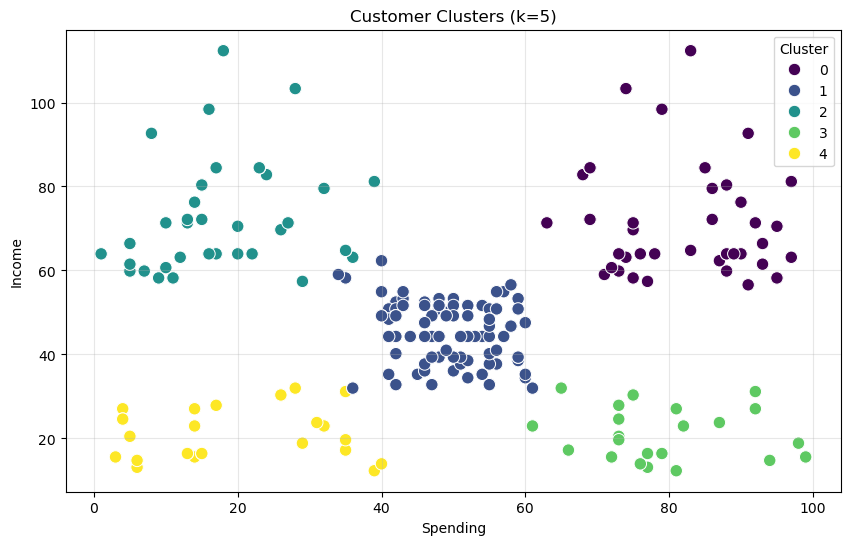

In [26]:
# Create the scatter plot with a legend using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_master,
                x='spending',
                y='income',
                hue='cluster',
                palette='viridis',
                s=80,
                alpha=1.0,
                legend='full')
plt.xlabel('Spending')
plt.ylabel('Income')
plt.title('Customer Clusters (k=5)')
plt.grid(True, alpha=0.3)
plt.legend(title='Cluster')
plt.savefig('customer_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

### Key findings
There are five distinct customer segments. Most of them are clustered in the middle of the axes, middle income, middle spenders that tend to spend 40 - 55 GBP on purchases from Turtle Games. 

Next steps will be to
 - Label each of the five clusters
 - Identify high value groups
 - Create subsets of existing customers that match the clusters in identified high value groups
 - Repeat regression exercise on the high value subsets

In [27]:
# Group by cluster and calculate key stats
cluster_summary = cluster_master.groupby('cluster').agg({
    'spending': ['count', 'mean', 'min', 'max'],
    'income': ['mean', 'min', 'max'],
    'loyalty': ['mean'],
    'age' : ['mean', 'min', 'max']
}).round(2)

print(cluster_summary)

        spending                income                 loyalty    age        
           count   mean min max   mean    min     max     mean   mean min max
cluster                                                                      
0            356  82.01  63  97  73.24  56.58  112.34  3988.24  35.59  18  72
1            774  49.53  34  61  44.42  31.98   62.32  1420.38  42.13  17  72
2            330  17.42   1  39  74.83  57.40  112.34   911.76  40.67  17  72
3            269  79.42  61  99  20.35  12.30   31.98   971.94  31.60  17  71
4            271  19.76   3  40  20.42  12.30   31.98   275.06  43.51  17  72


In [28]:
cluster_master.describe()

,age,income,spending,loyalty,product,cluster
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500,1.662500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839,1.289351
min,17.000000,12.300000,1.000000,25.000000,107.000000,0.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000,1.000000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000,1.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000,3.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000,4.000000


In [29]:
cluster_master.head()

,gender,age,income,spending,loyalty,education,language,platform,product,cluster
0,Male,18,12.30,39,210,graduate,EN,Web,453,4
1,Male,23,12.30,81,524,graduate,EN,Web,466,3
2,Female,22,13.12,6,40,graduate,EN,Web,254,4
3,Female,25,13.12,77,562,graduate,EN,Web,263,3
4,Female,33,13.94,40,366,graduate,EN,Web,291,4


In [30]:
cluster_0 = cluster_master[cluster_master['cluster'] == 0].copy()

In [31]:
cluster_1 = cluster_master[cluster_master['cluster'] == 1].copy()

In [32]:
cluster_3 = cluster_master[cluster_master['cluster'] == 3].copy()

In [33]:
cluster_0.head()

,gender,age,income,spending,loyalty,education,language,platform,product,cluster
123,Male,39,56.58,91,3634,graduate,EN,Web,5510,0
125,Female,33,57.40,77,2900,graduate,EN,Web,8235,0
127,Male,38,58.22,95,3866,postgraduate,EN,Web,2849,0
129,Male,38,58.22,75,3052,graduate,EN,Web,2874,0
131,Male,39,58.22,75,3082,postgraduate,EN,Web,2457,0


In [34]:
cluster_1.head()

,gender,age,income,spending,loyalty,education,language,platform,product,cluster
42,Male,46,31.98,36,849,diploma,EN,Web,2829,1
43,Female,33,31.98,61,1280,graduate,EN,Web,629,1
46,Female,49,32.80,55,1338,graduate,EN,Web,3667,1
47,Female,29,32.80,47,942,postgraduate,EN,Web,3678,1
48,Female,29,32.80,42,842,graduate,EN,Web,2079,1


In [35]:
cluster_3.head()

,gender,age,income,spending,loyalty,education,language,platform,product,cluster
1,Male,23,12.30,81,524,graduate,EN,Web,466,3
3,Female,25,13.12,77,562,graduate,EN,Web,263,3
5,Female,24,13.94,76,573,PhD,EN,Web,977,3
7,Female,25,14.76,94,772,graduate,EN,Web,1012,3
9,Female,32,15.58,72,724,PhD,EN,Web,1459,3


# Simple Linear Regression - higher value value customer segments (0, 1 and 3)

### Cluster_0 Spending vs Loyalty

In [36]:
# Define independent variable.
x_spending = cluster_0['spending'].values.reshape(-1, 1)

# Define dependent variable.
y_loyalty = cluster_0['loyalty'].values.reshape(-1, 1)

# Create model and print summary of metrics.
lm_spending = LinearRegression()
lm_spending.fit(x_spending, y_loyalty)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
# Extract the estimated parameters.
print("Estimated parameters:")
print(f"Intercept: {lm_spending.intercept_[0]}")
print(f"Coefficient: {lm_spending.coef_[0][0]}")

# Extract the standard errors.
print("\nNote: Standard errors not available in sklearn - use statsmodels for statistical significance")

# Extract the predicted values.
y_pred_spending = lm_spending.predict(x_spending)
print(f"\nPredicted values (first 10):")
print(y_pred_spending[:10].flatten())

Estimated parameters:
Intercept: 323.9216118624681
Coefficient: 44.682202643499274

Note: Standard errors not available in sklearn - use statsmodels for statistical significance

Predicted values (first 10):
[4390.00205242 3764.45121541 4568.73086299 3675.08681012 3675.08681012
 3496.35799955 4255.95544449 3585.72240484 3541.04020219 4479.36645771]


In [38]:
intercept = lm_spending.intercept_[0]
coefficient = lm_spending.coef_[0][0]

regression_table_spending = pd.DataFrame({
    'Variable': ['Intercept', 'Spending'],
    'Coefficient': [intercept, coefficient]
})

print(regression_table_spending)

    Variable  Coefficient
0  Intercept   323.921612
1   Spending    44.682203


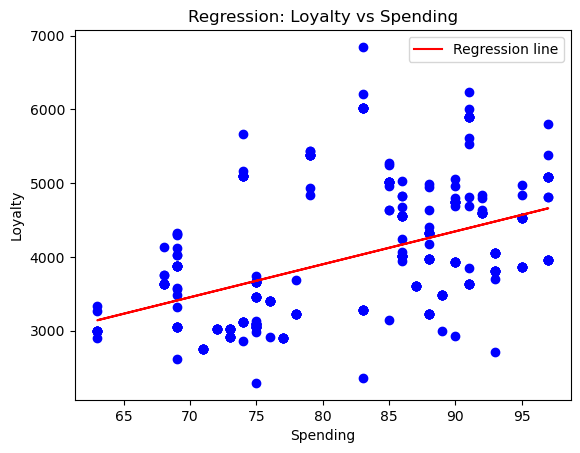

In [39]:
# Plot the graph with a regression line.
plot_loyalty_regression(x_spending, lm_spending, 'Spending', 'cluster_0_spending_plot.png')

In [40]:
r2 = lm_spending.score(x_spending, y_loyalty)
print(f"R-squared for Cluster 0: {r2:.3f}")

R-squared for Cluster 0: 0.216


### CLuster_0 Income vs Loyalty

In [41]:
# Define independent variable.
x_income = cluster_0['income'].values.reshape(-1, 1)

# Define dependent variable.
y_loyalty = cluster_0['loyalty'].values.reshape(-1, 1)

# Create model and print summary of metrics.
lm_income = LinearRegression()
lm_income.fit(x_income, y_loyalty)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
# Extract the estimated parameters.
print("Estimated parameters:")
print(f"Intercept: {lm_income.intercept_[0]}")
print(f"Coefficient: {lm_income.coef_[0][0]}")

# Extract the standard errors.
print("\nNote: Standard errors not available in sklearn - use statsmodels for statistical significance")

# Extract the predicted values.
y_pred_income = lm_income.predict(x_income)
print(f"\nPredicted values (first 10):")
print(y_pred_income[:10].flatten())

Estimated parameters:
Intercept: 79.72841865120654
Coefficient: 53.36558376653766

Note: Standard errors not available in sklearn - use statsmodels for statistical significance

Predicted values (first 10):
[3099.15314816 3142.91292685 3186.67270554 3186.67270554 3186.67270554
 3230.43248423 3274.19226292 3274.19226292 3317.9520416  3361.71182029]


In [43]:
# Set the the X coefficient and the constant to generate the regression table.
intercept = lm_income.intercept_[0]
coefficient = lm_income.coef_[0][0]

regression_table_income = pd.DataFrame({
    'Variable': ['Intercept', 'Income'],
    'Coefficient': [intercept, coefficient]
})

# View the output.
print(regression_table_income)

    Variable  Coefficient
0  Intercept    79.728419
1     Income    53.365584


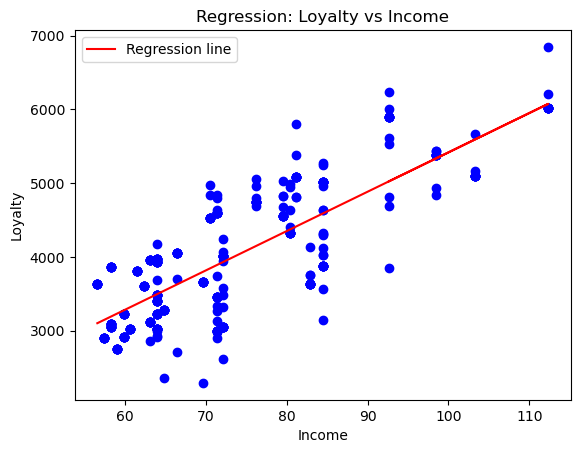

In [44]:
# Plot the graph with a regression line.
plot_loyalty_regression(x_income, lm_income, 'Income', 'cluster_0_income_plot.png')

In [45]:
r2 = lm_income.score(x_income, y_loyalty)
print(f"R-squared for Cluster 0: {r2:.3f}")

R-squared for Cluster 0: 0.649


### Cluster_1 spending vs loyalty

In [46]:
# Define independent variable.
x_spending = cluster_1['spending'].values.reshape(-1, 1)

# Define dependent variable.
y_loyalty = cluster_1['loyalty'].values.reshape(-1, 1)

# Create model and print summary of metrics.
lm_spending = LinearRegression()
lm_spending.fit(x_spending, y_loyalty)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
# Extract the estimated parameters.
print("Estimated parameters:")
print(f"Intercept: {lm_spending.intercept_[0]}")
print(f"Coefficient: {lm_spending.coef_[0][0]}")

# Extract the standard errors.
print("\nNote: Standard errors not available in sklearn - use statsmodels for statistical significance")

# Extract the predicted values.
y_pred_spending = lm_spending.predict(x_spending)
print(f"\nPredicted values (first 10):")
print(y_pred_spending[:10].flatten())

Estimated parameters:
Intercept: 405.23588732918427
Coefficient: 20.495706991006138

Note: Standard errors not available in sklearn - use statsmodels for statistical significance

Predicted values (first 10):
[1143.08133901 1655.47401378 1532.49977183 1368.53411591 1266.05558095
 1266.05558095 1471.01265086 1634.97830679 1512.00406484 1634.97830679]


In [48]:
intercept = lm_spending.intercept_[0]
coefficient = lm_spending.coef_[0][0]

regression_table_spending = pd.DataFrame({
    'Variable': ['Intercept', 'Spending'],
    'Coefficient': [intercept, coefficient]
})

print(regression_table_spending)

    Variable  Coefficient
0  Intercept   405.235887
1   Spending    20.495707


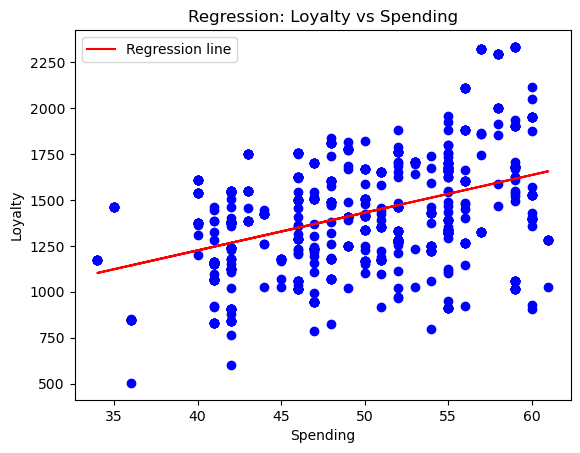

In [49]:
# Plot the graph with a regression line.
plot_loyalty_regression(x_spending, lm_spending, 'Spending', 'cluster_1_spending_plot.png')

In [50]:
r2 = lm_spending.score(x_spending, y_loyalty)
print(f"R-squared for Cluster 1: {r2:.3f}")

R-squared for Cluster 1: 0.170


### Cluster_1 income vs loyalty

In [51]:
# Define independent variable.
x_income = cluster_1['income'].values.reshape(-1, 1)

# Define dependent variable.
y_loyalty = cluster_1['loyalty'].values.reshape(-1, 1)

# Create model and print summary of metrics.
lm_income = LinearRegression()
lm_income.fit(x_income, y_loyalty)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
# Extract the estimated parameters.
print("Estimated parameters:")
print(f"Intercept: {lm_income.intercept_[0]}")
print(f"Coefficient: {lm_income.coef_[0][0]}")

# Extract the standard errors.
print("\nNote: Standard errors not available in sklearn - use statsmodels for statistical significance")

# Extract the predicted values.
y_pred_income = lm_income.predict(x_income)
print(f"\nPredicted values (first 10):")
print(y_pred_income[:10].flatten())

Estimated parameters:
Intercept: 338.64766148638205
Coefficient: 24.353091930676843

Note: Standard errors not available in sklearn - use statsmodels for statistical significance

Predicted values (first 10):
[1117.45954143 1117.45954143 1137.42907681 1137.42907681 1137.42907681
 1137.42907681 1177.36814758 1177.36814758 1197.33768296 1197.33768296]


In [53]:
# Set the the X coefficient and the constant to generate the regression table.
intercept = lm_income.intercept_[0]
coefficient = lm_income.coef_[0][0]

regression_table_income = pd.DataFrame({
    'Variable': ['Intercept', 'Income'],
    'Coefficient': [intercept, coefficient]
})

# View the output.
print(regression_table_income)

    Variable  Coefficient
0  Intercept   338.647661
1     Income    24.353092


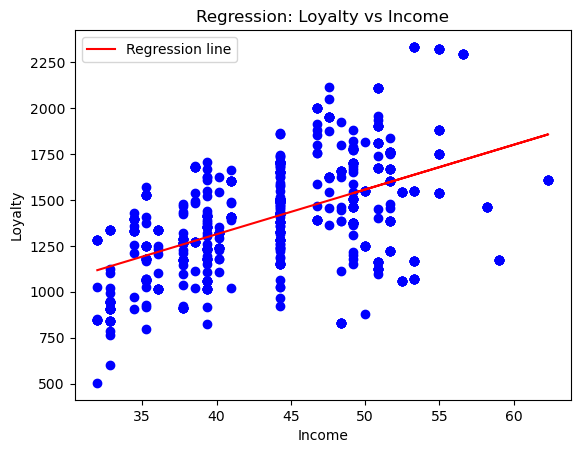

In [54]:
# Plot the graph with a regression line.
plot_loyalty_regression(x_income, lm_income, 'Income', 'cluster_1_income_plot.png')

In [55]:
r2 = lm_income.score(x_income, y_loyalty)
print(f"R-squared for Cluster 1: {r2:.3f}")

R-squared for Cluster 1: 0.286


### Cluster_3 spending vs loyalty

In [56]:
# Define independent variable.
x_spending = cluster_3['spending'].values.reshape(-1, 1)

# Define dependent variable.
y_loyalty = cluster_3['loyalty'].values.reshape(-1, 1)

# Create model and print summary of metrics.
lm_spending = LinearRegression()
lm_spending.fit(x_spending, y_loyalty)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
# Extract the estimated parameters.
print("Estimated parameters:")
print(f"Intercept: {lm_spending.intercept_[0]}")
print(f"Coefficient: {lm_spending.coef_[0][0]}")

# Extract the standard errors.
print("\nNote: Standard errors not available in sklearn - use statsmodels for statistical significance")

# Extract the predicted values.
y_pred_spending = lm_spending.predict(x_spending)
print(f"\nPredicted values (first 10):")
print(y_pred_spending[:10].flatten())

Estimated parameters:
Intercept: 296.0206017189257
Coefficient: 8.511138797809718

Note: Standard errors not available in sklearn - use statsmodels for statistical significance

Predicted values (first 10):
[ 985.42284434  951.37828915  942.86715035 1096.06764871  908.82259516
 1138.6233427   951.37828915  968.40056675  857.75576237 1130.1122039 ]


In [58]:
intercept = lm_spending.intercept_[0]
coefficient = lm_spending.coef_[0][0]

regression_table_spending = pd.DataFrame({
    'Variable': ['Intercept', 'Spending'],
    'Coefficient': [intercept, coefficient]
})

print(regression_table_spending)

    Variable  Coefficient
0  Intercept   296.020602
1   Spending     8.511139


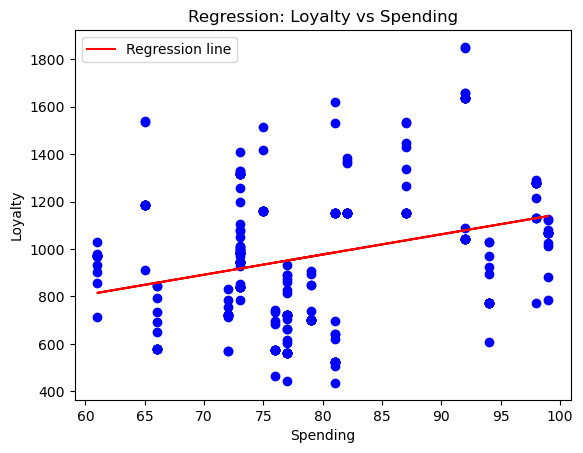

In [59]:
# Plot the graph with a regression line.
plot_loyalty_regression(x_spending, lm_spending, 'Spending', 'cluster_3_spending_plot.png')

In [60]:
r2 = lm_spending.score(x_spending, y_loyalty)
print(f"R-squared for Cluster 3: {r2:.3f}")

R-squared for Cluster 3: 0.089


### Cluster_3 income vs loyalty

In [61]:
# Define independent variable.
x_income = cluster_3['income'].values.reshape(-1, 1)

# Define dependent variable.
y_loyalty = cluster_3['loyalty'].values.reshape(-1, 1)

# Create model and print summary of metrics.
lm_income = LinearRegression()
lm_income.fit(x_income, y_loyalty)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
# Extract the estimated parameters.
print("Estimated parameters:")
print(f"Intercept: {lm_income.intercept_[0]}")
print(f"Coefficient: {lm_income.coef_[0][0]}")

# Extract the standard errors.
print("\nNote: Standard errors not available in sklearn - use statsmodels for statistical significance")

# Extract the predicted values.
y_pred_income = lm_income.predict(x_income)
print(f"\nPredicted values (first 10):")
print(y_pred_income[:10].flatten())

Estimated parameters:
Intercept: 154.94988308726715
Coefficient: 40.13988344581603

Note: Standard errors not available in sklearn - use statsmodels for statistical significance

Predicted values (first 10):
[648.67044947 681.5851539  714.49985832 747.41456275 780.32926717
 780.32926717 813.2439716  813.2439716  846.15867602 911.98808488]


In [63]:
# Set the the X coefficient and the constant to generate the regression table.
intercept = lm_income.intercept_[0]
coefficient = lm_income.coef_[0][0]

regression_table_income = pd.DataFrame({
    'Variable': ['Intercept', 'Income'],
    'Coefficient': [intercept, coefficient]
})

# View the output.
print(regression_table_income)

    Variable  Coefficient
0  Intercept   154.949883
1     Income    40.139883


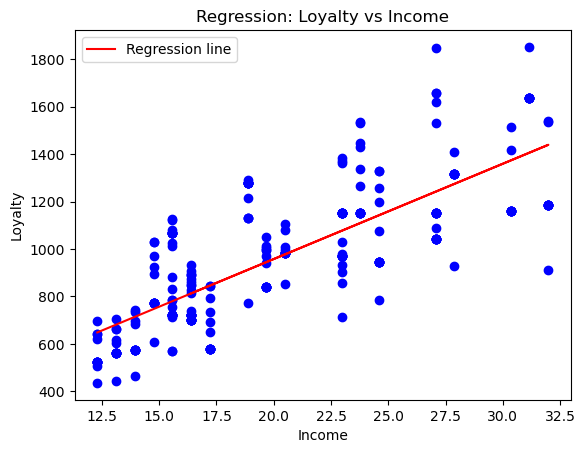

In [64]:
# Plot the graph with a regression line.
plot_loyalty_regression(x_income, lm_income, 'Income', 'cluster_3_income_plot.png')

In [65]:
r2 = lm_income.score(x_income, y_loyalty)
print(f"R-squared for Cluster 3: {r2:.3f}")

R-squared for Cluster 3: 0.605


### Key findings

Cluster_0

 - Income is the strongest predictor (R² = 0.649)
 - Every £1,000 increase in income yields approximately  53 loyalty points. Spending is weaker (R² = 0.216)

Cluster_1

 - Both predictors are weak (R² = 0.286 income, 0.17 spending), dropped for further modelling.

Cluster_3

 - Income strong predictor (R² = 0.605)
 - Every £1,000 increase yieds approximately 40 loyalty points
 - Spending is negligible (R² = 0.089)

# Decision trees

In [66]:
# Create dedicated DataFrames for tree analysis
cluster_0_tree = cluster_0[['income', 'spending', 'loyalty']].copy()
cluster_3_tree = cluster_3[['income', 'spending', 'loyalty']].copy()

Progress to build a model for cluster_0 and cluster_3 using features;

spending - the strongest predictor from earlier "all customer" regression models

income - the strongest overall predictor from the full dataset models

Setting max_depth=3 creates a shallow tree that finds the 2-3 most important spending or income thresholds for predicting loyalty within this customer group. This forces the model to be easier to interpret and provides clear business rules like "If income is above £x, loyalty is typically high", rather than complicated predictions that are difficult to action

### Cluster 0

In [67]:
# Specify Y (target variable)
y = cluster_0_tree['loyalty']

# Specify X (feature variables)
X = cluster_0_tree.drop('loyalty', axis=1)

In [68]:
# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and fit the tree with limited depth for simple rules
tree_cluster0 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_cluster0.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [69]:
X.shape

(356, 2)

In [70]:
X.columns.tolist()

['income', 'spending']

In [71]:
y.shape

(356,)

In [72]:
from sklearn.model_selection import train_test_split

# Create train and test data sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [73]:
# Create Decision Tree Regressor with max_depth=3
dtree_cluster0 = DecisionTreeRegressor(max_depth=3, random_state=42)

# Fit the model
dtree_cluster0.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [74]:
# Make predictions
y_pred = dtree_cluster0.predict(X_test)

# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R-squared:", r2)

MSE: 153568.1752693512
R-squared: 0.8325418127118521


In [75]:
from sklearn.tree import export_text
tree_rules = export_text(dtree_cluster0, feature_names=['income', 'spending'])
print(tree_rules)

|--- income <= 74.21
|   |--- spending <= 84.50
|   |   |--- income <= 63.55
|   |   |   |--- value: [2977.36]
|   |   |--- income >  63.55
|   |   |   |--- value: [3215.75]
|   |--- spending >  84.50
|   |   |--- income <= 68.47
|   |   |   |--- value: [3742.98]
|   |   |--- income >  68.47
|   |   |   |--- value: [4367.45]
|--- income >  74.21
|   |--- spending <= 71.50
|   |   |--- income <= 83.64
|   |   |   |--- value: [3716.89]
|   |   |--- income >  83.64
|   |   |   |--- value: [3995.80]
|   |--- spending >  71.50
|   |   |--- income <= 80.77
|   |   |   |--- value: [4637.73]
|   |   |--- income >  80.77
|   |   |   |--- value: [5288.98]



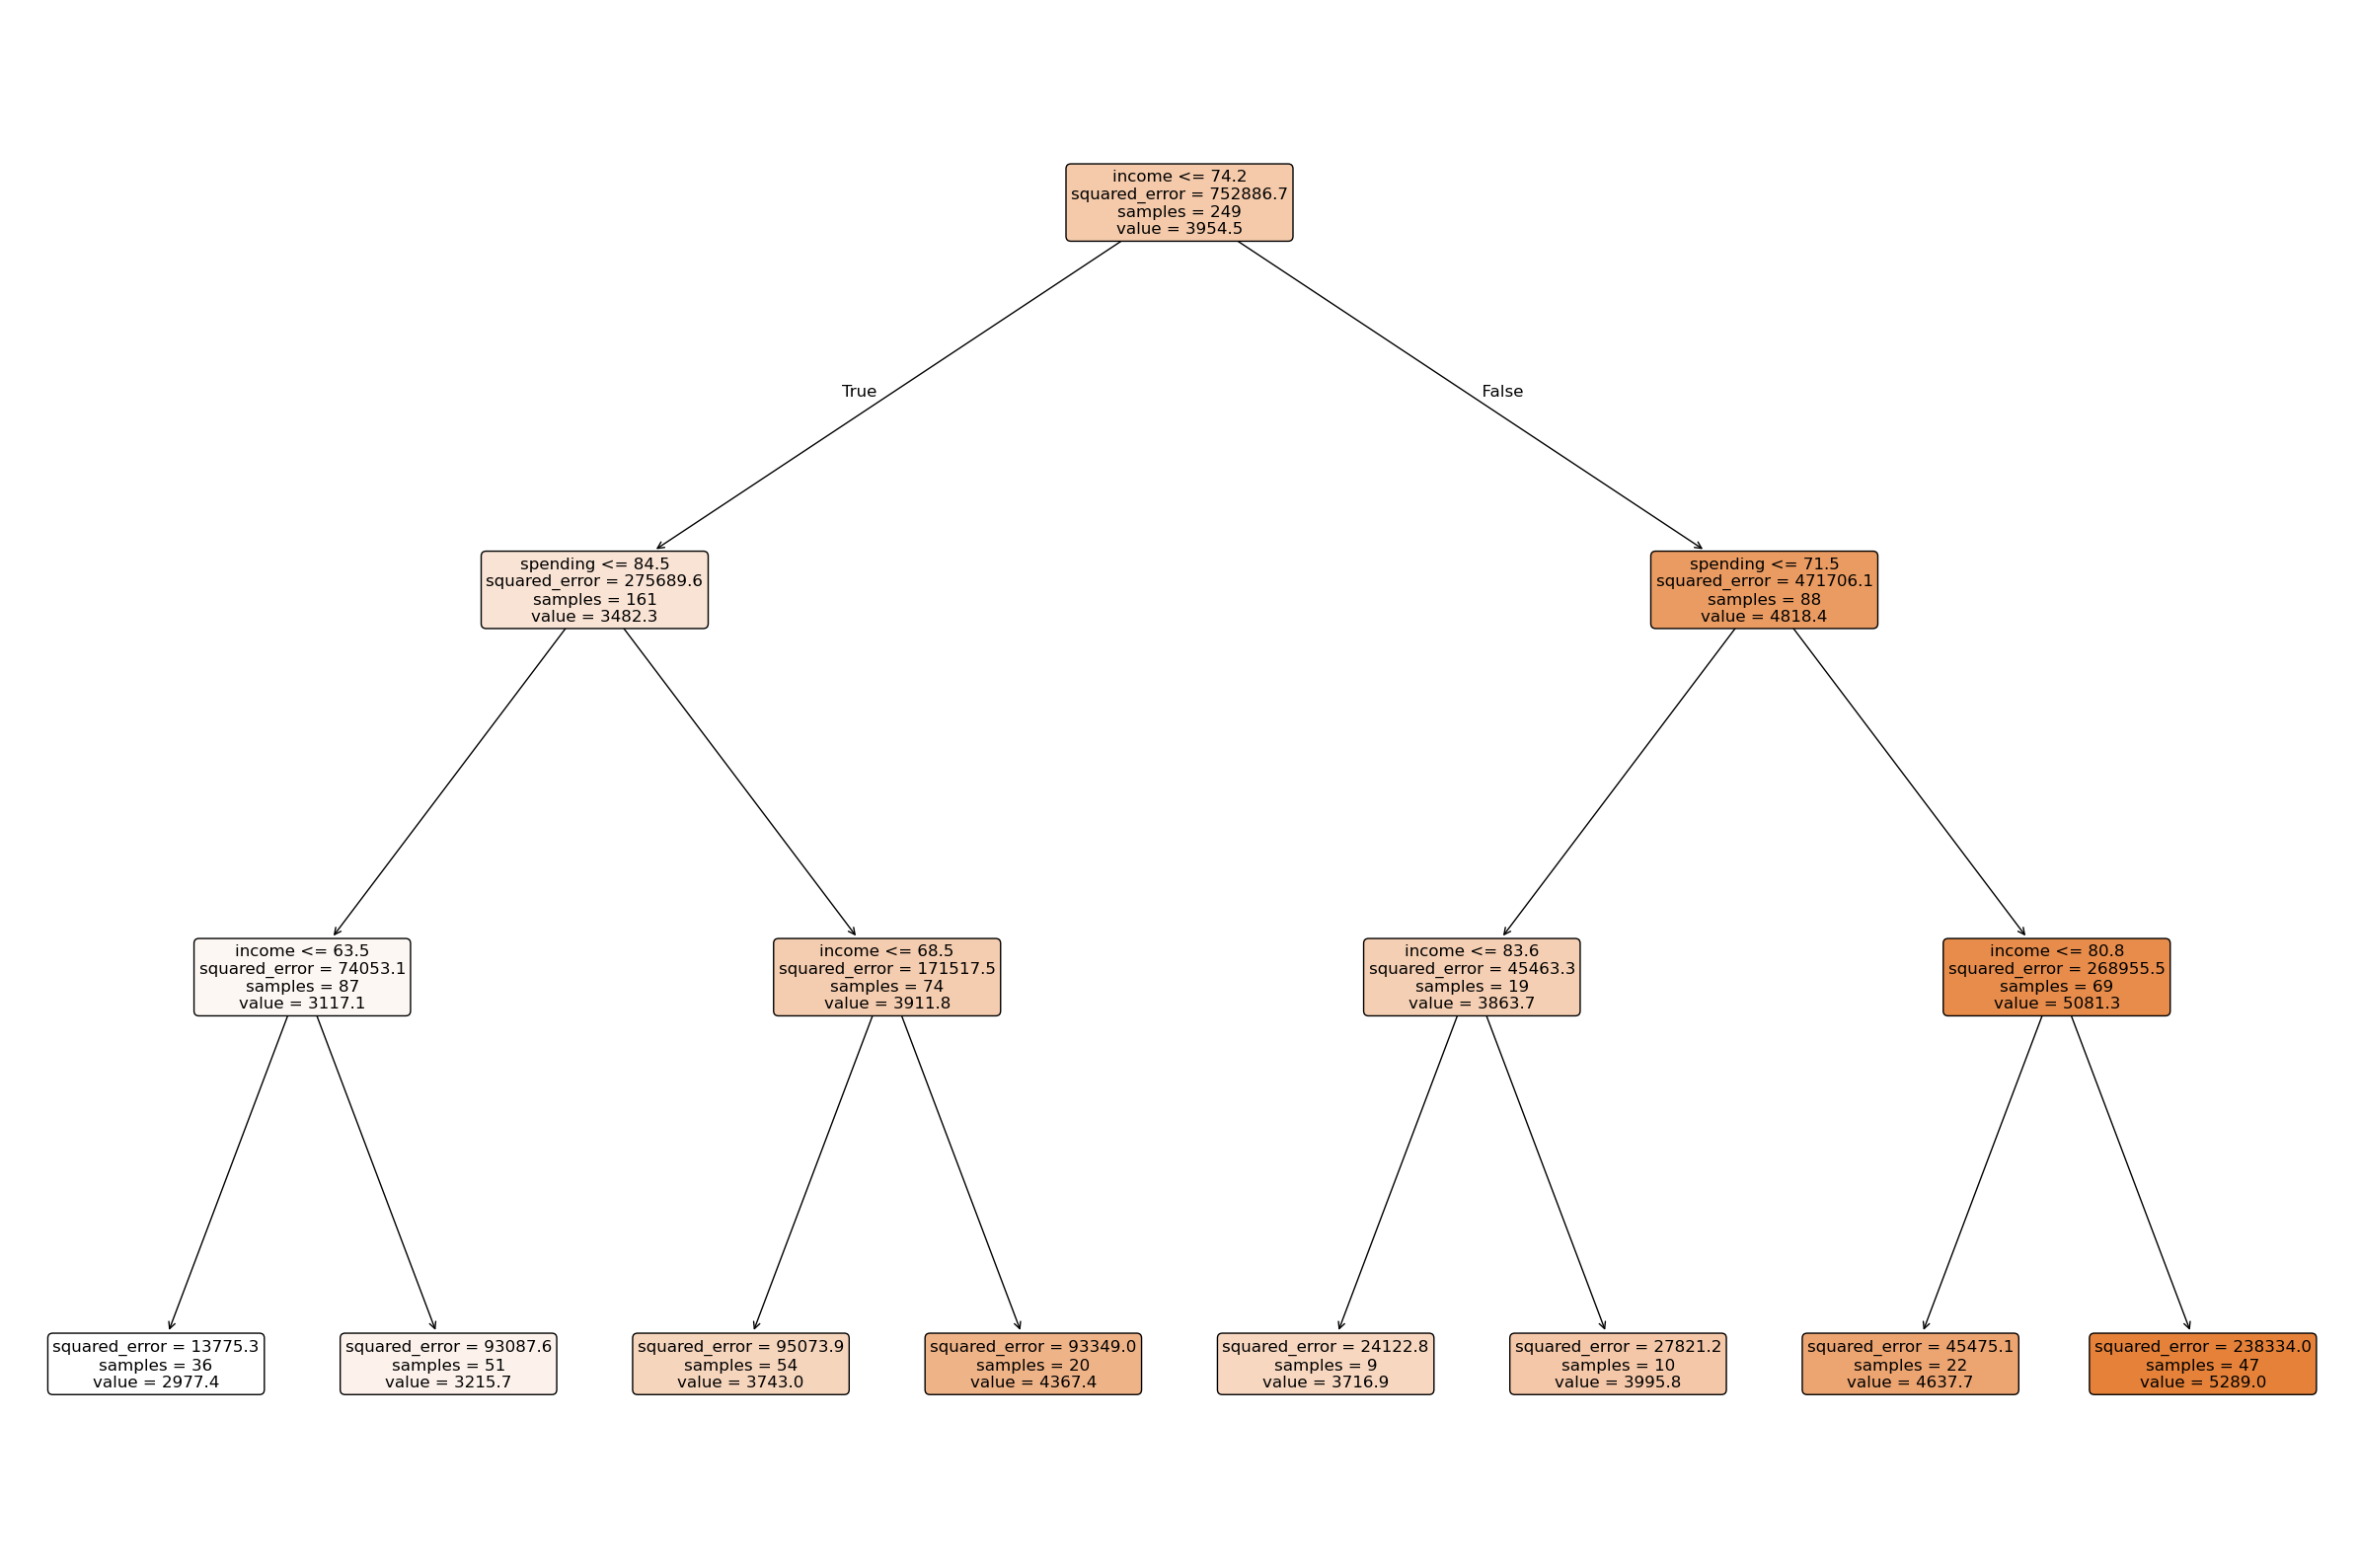

In [76]:
from sklearn import tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(24, 16))
tree.plot_tree(dtree_cluster0,
               feature_names=['income', 'spending'],
               filled=True,
               fontsize=12,
               rounded=True,
               precision=1)
plt.tight_layout()
plt.savefig('decision_tree_cluster0.png', dpi=300, bbox_inches='tight')
plt.show()

### Cluster 3

In [77]:
# Specify Y (target variable)
y = cluster_3_tree['loyalty']

# Specify X (feature variables)
X = cluster_3_tree.drop('loyalty', axis=1)

In [78]:
# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and fit the tree with limited depth for simple rules
tree_cluster3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_cluster3.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [79]:
X.shape

(269, 2)

In [80]:
X.columns.tolist()

['income', 'spending']

In [81]:
y.shape

(269,)

In [82]:
from sklearn.model_selection import train_test_split

# Create train and test data sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [83]:
# Create Decision Tree Regressor with max_depth=3
dtree_cluster3 = DecisionTreeRegressor(max_depth=3, random_state=42)

# Fit the model
dtree_cluster3.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [84]:
# Make predictions
y_pred = dtree_cluster3.predict(X_test)

# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R-squared:", r2)

MSE: 18150.30681416642
R-squared: 0.8343360884854949


In [85]:
from sklearn.tree import export_text
tree_rules = export_text(dtree_cluster3, feature_names=['income', 'spending'])
print(tree_rules)

|--- income <= 18.04
|   |--- spending <= 96.50
|   |   |--- income <= 14.35
|   |   |   |--- value: [597.55]
|   |   |--- income >  14.35
|   |   |   |--- value: [750.35]
|   |--- spending >  96.50
|   |   |--- value: [1027.36]
|--- income >  18.04
|   |--- spending <= 74.00
|   |   |--- income <= 26.24
|   |   |   |--- value: [968.17]
|   |   |--- income >  26.24
|   |   |   |--- value: [1231.67]
|   |--- spending >  74.00
|   |   |--- income <= 30.75
|   |   |   |--- value: [1224.02]
|   |   |--- income >  30.75
|   |   |   |--- value: [1637.00]



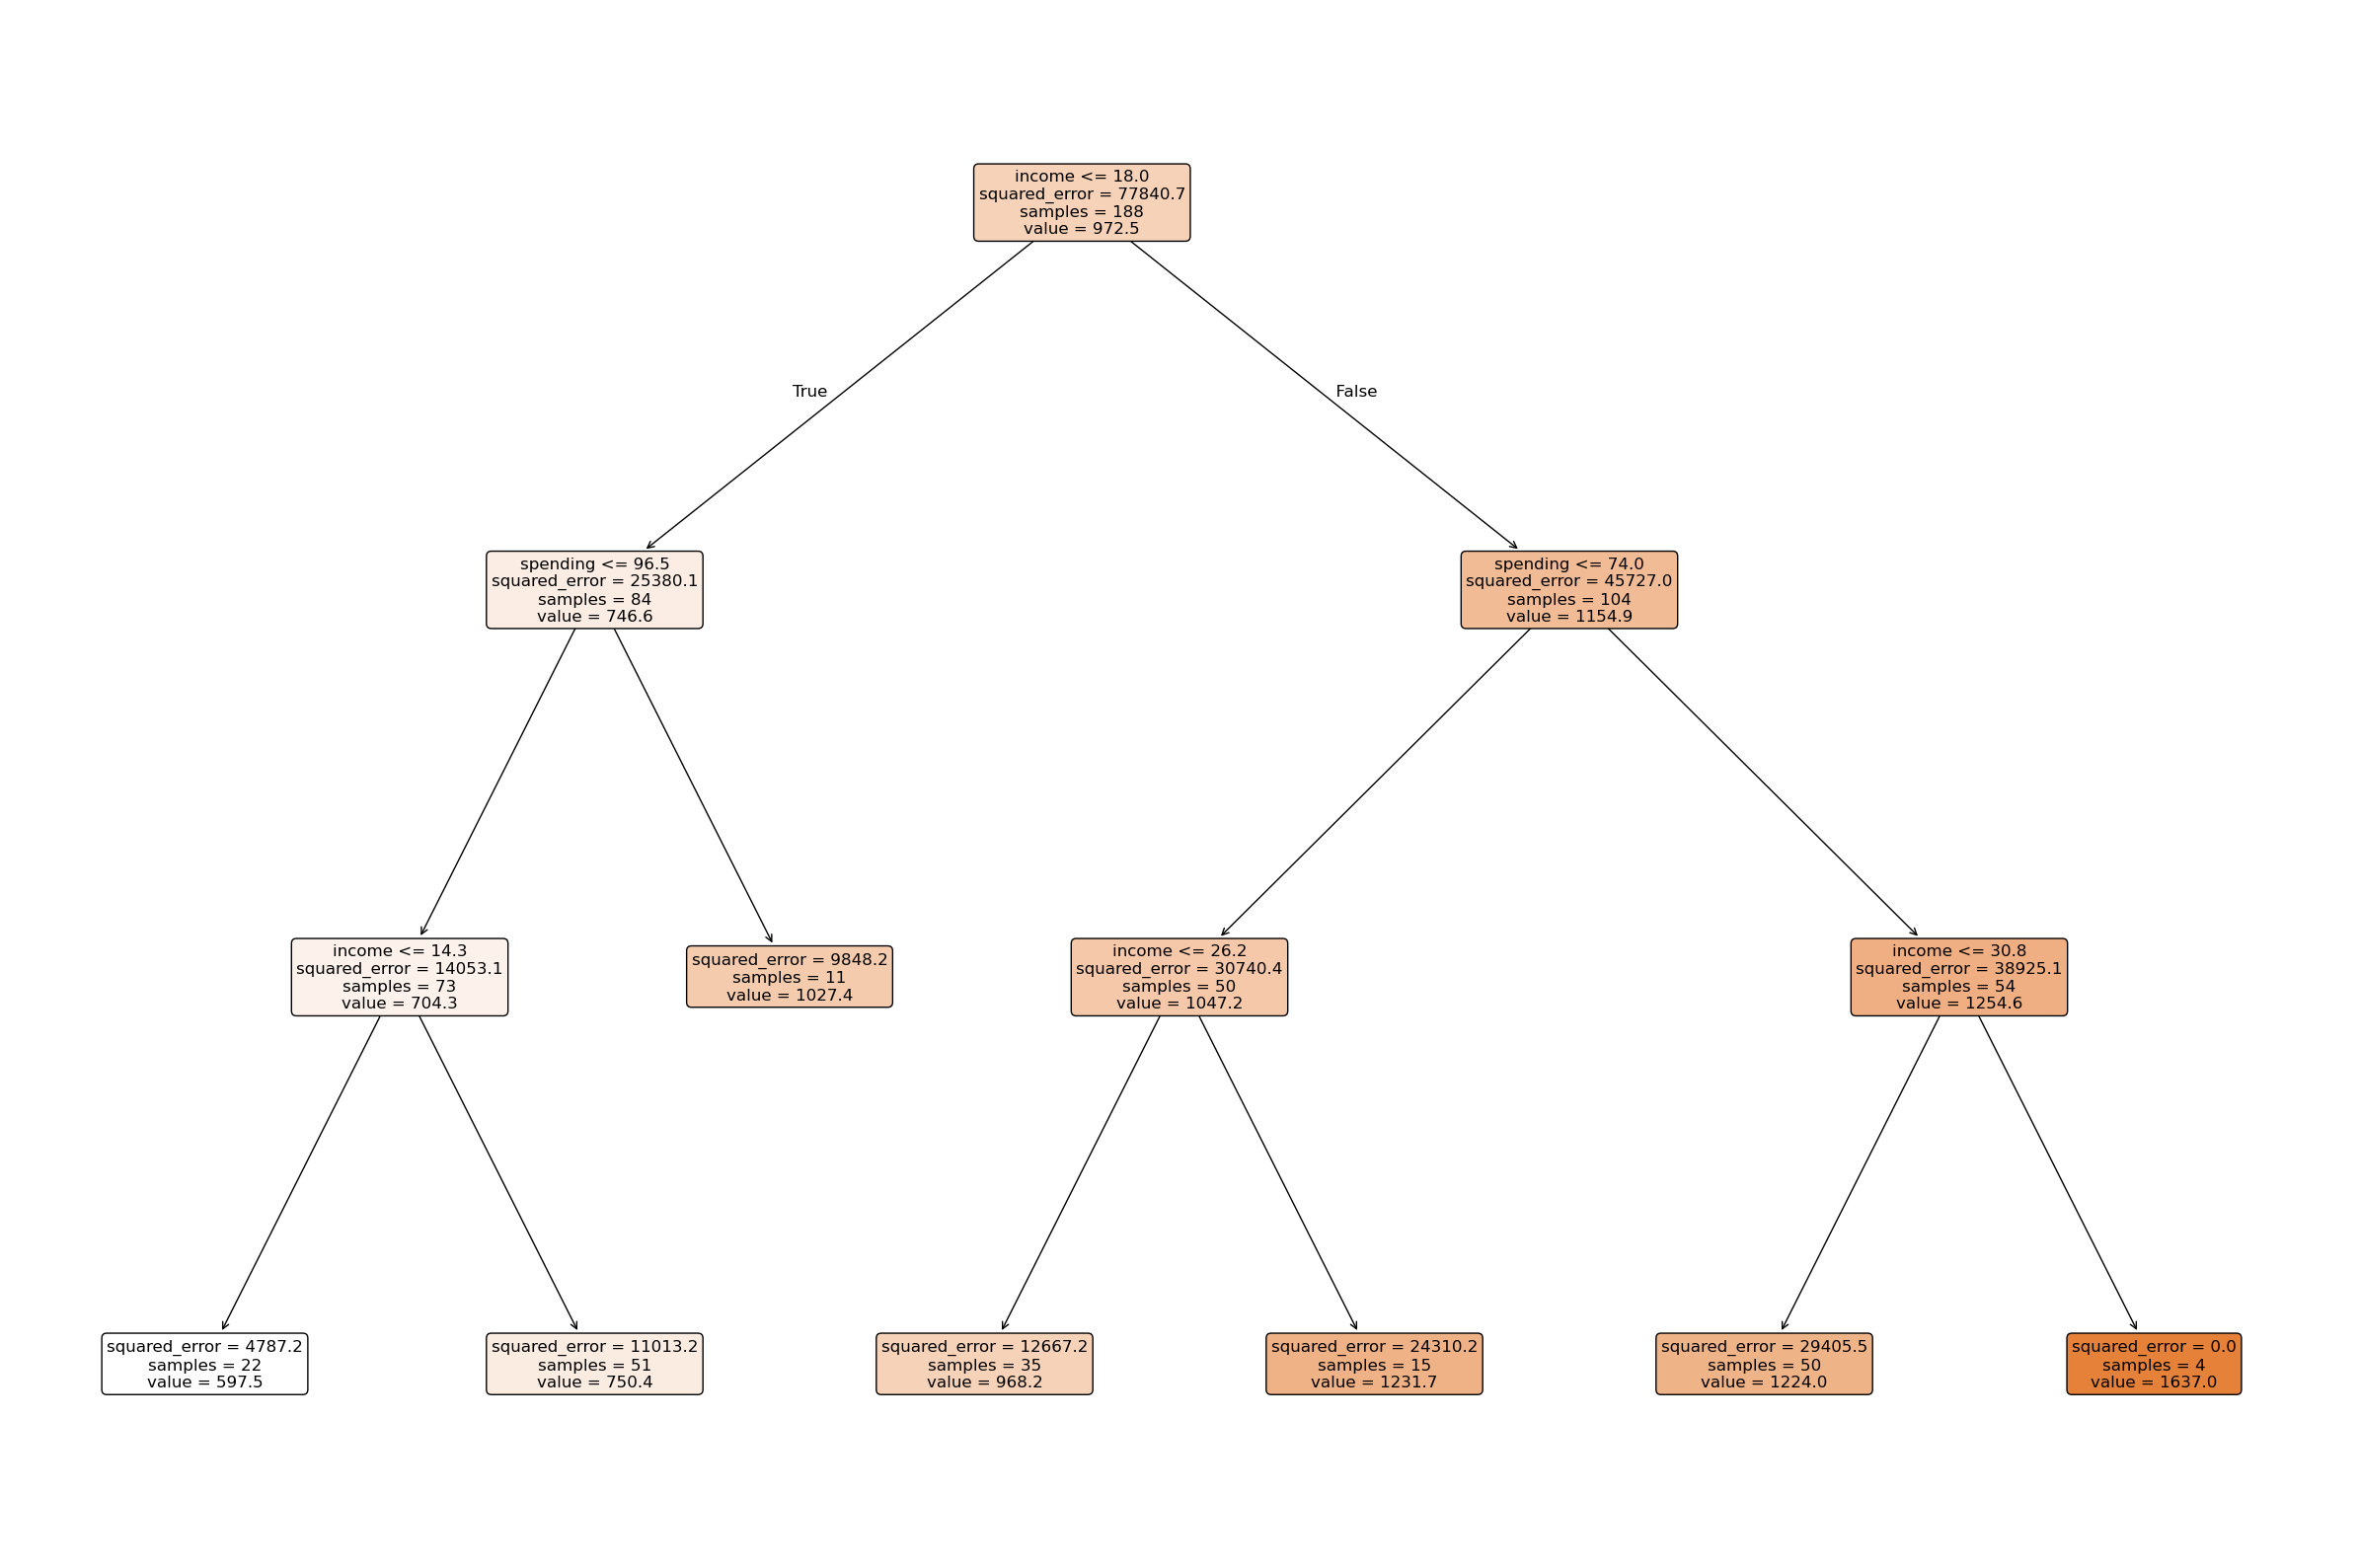

In [86]:
from sklearn import tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(24, 16))
tree.plot_tree(dtree_cluster3,
               feature_names=['income', 'spending'],
               filled=True,
               fontsize=12,
               rounded=True,
               precision=1)
plt.tight_layout()
plt.savefig('decision_tree_cluster3.png', dpi=300, bbox_inches='tight')
plt.show()

### Key findings
Cluster 0: Loyalty is highest when income > £80.77k and spending > £71.50.

Cluster 3: spending > £74.00 is primary lever and income > £30.75k boosts loyalty further.

# Natural Language Processing

In [87]:
# Load the data set as nlp_master
nlp_master = pd.read_csv('turtle_review_text.csv')

In [88]:
# View top of data frame
nlp_master.head()

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\r\n\r\nYour unp...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


In [89]:
nlp_master.shape

(2000, 2)

In [90]:
nlp_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   review   2000 non-null   object
 1   summary  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


### Prepare the data for NLP

In [91]:
# Change all to lower case and join with a space
nlp_master['review'] = nlp_master['review'].apply(lambda x: " ".join(x.lower() for x in x.split()))
nlp_master['summary'] = nlp_master['summary'].apply(lambda x: " ".join(x.lower() for x in x.split()))

In [92]:
# Replace all the punctuation characters with spaces
nlp_master['review'] = nlp_master['review'].str.replace('[^\w\s]', '', regex=True)
nlp_master['summary'] = nlp_master['summary'].str.replace('[^\w\s]', '', regex=True)

In [93]:
# Check the number of duplicate values in the review column.
nlp_master.review.duplicated().sum()

50

In [94]:
# Check the number of duplicate values in the summary column.
nlp_master.summary.duplicated().sum()

649

In [95]:
# Remove duplicates and reset index
nlp_master = nlp_master.drop_duplicates(subset=['review'])
nlp_master = nlp_master.drop_duplicates(subset=['summary'])
nlp_master.reset_index(drop=True, inplace=True)

In [96]:
# compare top of data frame with previous version
nlp_master.head()

,review,summary
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...
2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,amazing buy bought it as a gift for our new dm...,five stars
4,as my review of gf9s previous screens these we...,money trap


### Tokenise and create wordclouds

In [97]:
# Create copy of data frame
nlp_token = nlp_master.copy()

In [98]:
# Ensure nltk is available in the environment
!pip install nltk

In [99]:
from nltk.tokenize import word_tokenize

# Apply tokenisation to both columns
nlp_token['review_tokens'] = nlp_token['review'].apply(word_tokenize)
nlp_token['summary_tokens'] = nlp_token['summary'].apply(word_tokenize)

# View DataFrame.
nlp_token.head()

,review,summary,review_tokens,summary_tokens
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...,"[when, it, comes, to, a, dms, screen, the, spa...","[the, fact, that, 50, of, this, space, is, was..."
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...,"[an, open, letter, to, galeforce9, your, unpai...","[another, worthless, dungeon, masters, screen,..."
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]"
3,amazing buy bought it as a gift for our new dm...,five stars,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]"
4,as my review of gf9s previous screens these we...,money trap,"[as, my, review, of, gf9s, previous, screens, ...","[money, trap]"


In [100]:
# Flatten tokens for reviews
all_review_tokens = []
for i in range(nlp_token.shape[0]):
    all_review_tokens = all_review_tokens + nlp_token['review_tokens'][i]

# Flatten tokens for summaries
all_summary_tokens = []
for i in range(nlp_token.shape[0]):
    all_summary_tokens = all_summary_tokens + nlp_token['summary_tokens'][i]

In [101]:
# Convert to strings
review_text = ' '.join(all_review_tokens)
summary_text = ' '.join(all_summary_tokens)

In [102]:
# Determine the frequency distribution

# Frequency distribution for reviews
fdist_review = FreqDist(all_review_tokens)

# Frequency distribution for summaries
fdist_summary = FreqDist(all_summary_tokens)

# Preview
print("Review Frequency Distribution:")
print(fdist_review)
print("\nSummary Frequency Distribution:")
print(fdist_summary)

Review Frequency Distribution:
<FreqDist with 7210 samples and 101009 outcomes>

Summary Frequency Distribution:
<FreqDist with 1549 samples and 8080 outcomes>


In [103]:
# Keep alphabetic chars, remove numbers and special chars
all_review_tokens_alpha = [token for token in all_review_tokens if token.isalpha()]
all_summary_tokens_alpha = [token for token in all_summary_tokens if token.isalpha()]

In [104]:
# Remove all the stopwords

# Download stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords

english_stopwords = set(stopwords.words('english'))

# Remove stopwords from cleaned review tokens
review_tokens_no_stop = [x for x in all_review_tokens_alpha if x.lower() not in english_stopwords]

# Remove stopwords from cleaned summary tokens
summary_tokens_no_stop = [x for x in all_summary_tokens_alpha if x.lower() not in english_stopwords]

# Warning may be encountered if stopwords corpus is already present and up‑to‑date. No action needed.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\toby_\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [105]:
# Rejoin cleaned tokens into single strings for word cloud
review_text_no_stop = ' '.join(review_tokens_no_stop)
summary_text_summaryt_no_stop = ' '.join(summary_tokens_no_stop)

In [106]:
# Join tokens into a single string
review_text_no_stop = ' '.join(review_tokens_no_stop)
summary_text_no_stop = ' '.join(summary_tokens_no_stop)

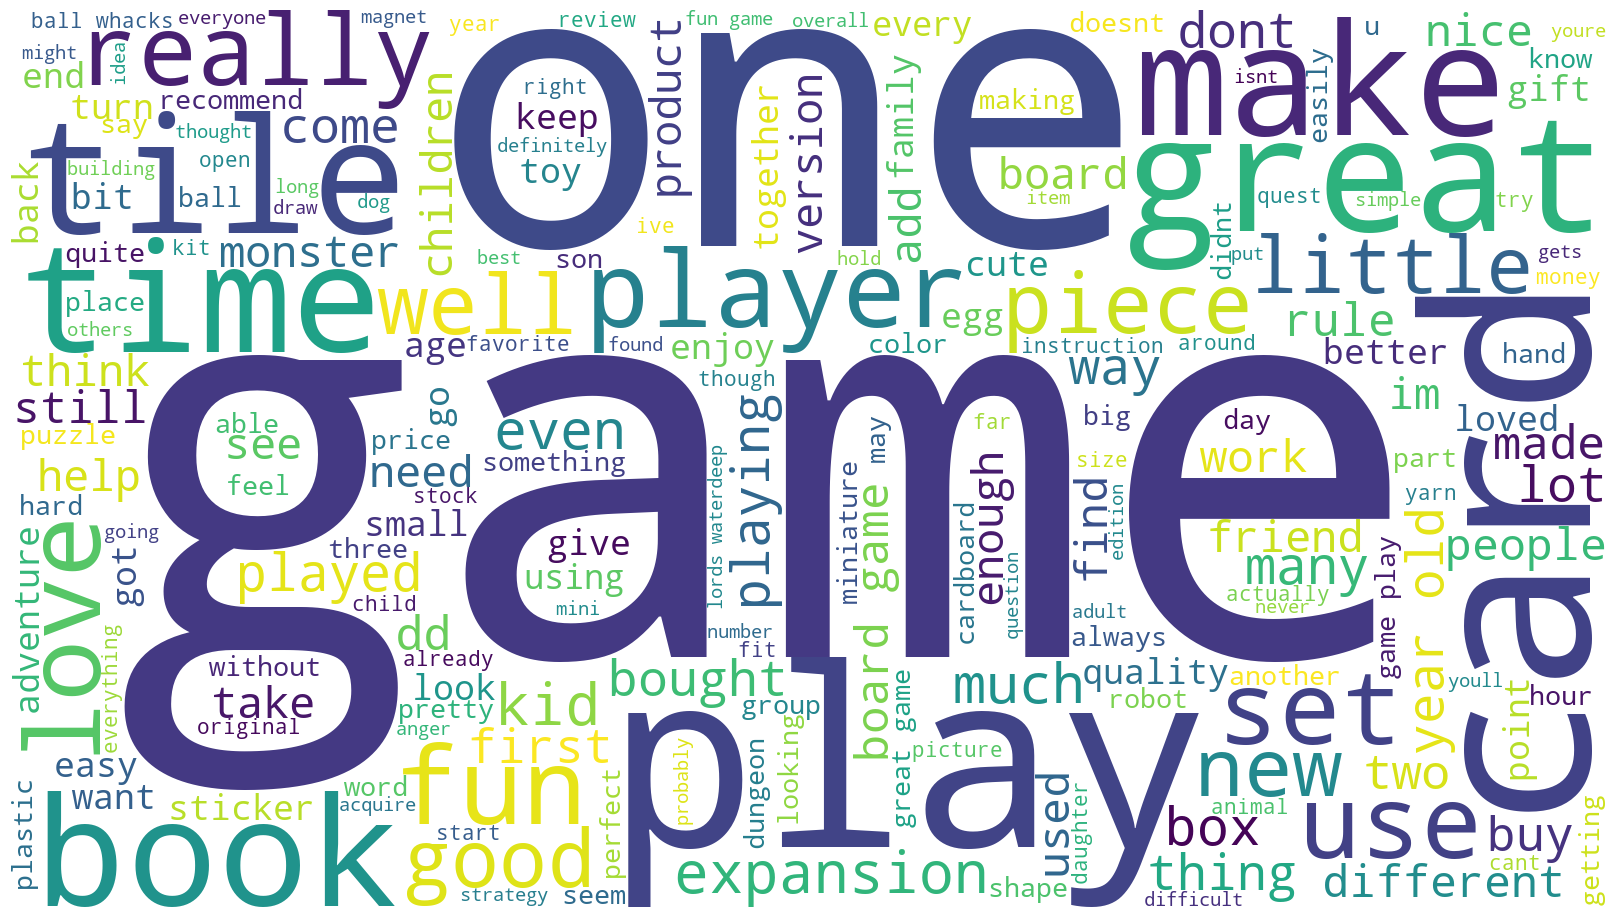

In [107]:
# Generate reviews wordcloud
generate_wordcloud(review_text_no_stop, 'viridis', 'wordcloud_reviews.png')

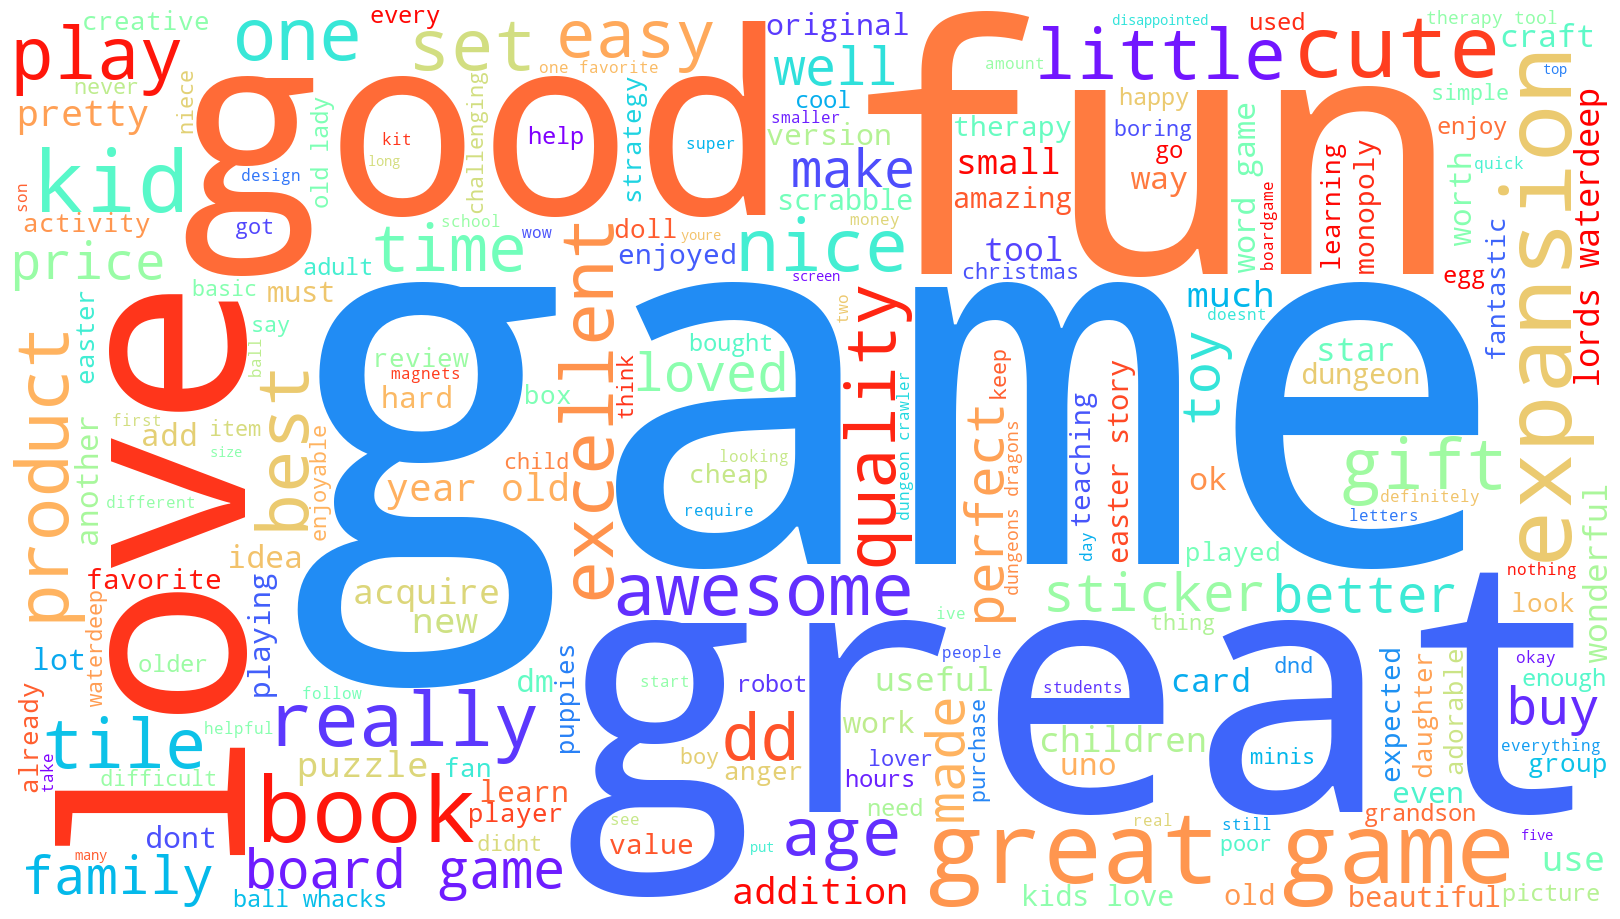

In [108]:
# Generate summaries wordcloud
generate_wordcloud(summary_text_no_stop, 'rainbow', 'wordcloud_summaries.png')

### key findings
The wordclouds contain very positive messages for impact in presentation but we need more in depth analysis of customer sentiment
Continue with vader to obtain analysis and use the "summarries" wordcloud to introduce the NLP section of the report

### Vader compound scores
Sentiment was assessed using VADER’s compound score, which is optimised for informal text and captures intensity better than simpler polarity measures (Textblob).

In [122]:
nlp_vader = nlp_master.copy()

In [123]:
# Import and initialise VADER sentiment analyser
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [124]:
# Calculate VADER compound sentiment scores
nlp_vader['review_sentiment'] = nlp_vader['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
nlp_vader['summary_sentiment'] = nlp_vader['summary'].apply(lambda x: sia.polarity_scores(x)['compound'])

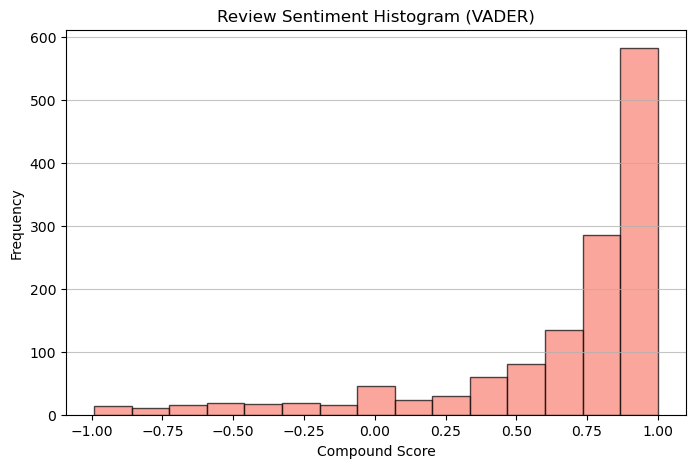

In [125]:
# Generate histogram for review sentiment
plot_sentiment_histogram(nlp_vader['review_sentiment'],
                         'Review Sentiment Histogram (VADER)',
                         'salmon',
                         'review_sentiment_histogram.png')

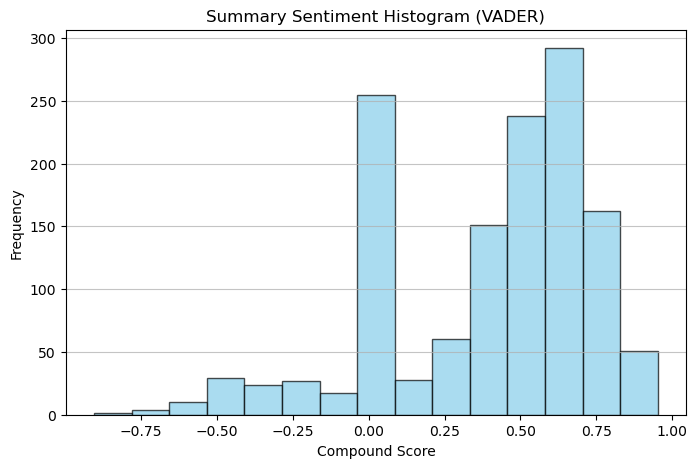

In [126]:
# Generate histogram for summary sentiment
plot_sentiment_histogram(nlp_vader['summary_sentiment'],
                         'Summary Sentiment Histogram (VADER)',
                         'skyblue',
                         'summary_sentiment_histogram.png')

### Key findings
Reviews are overwhelmingly positive, with most scores concentrated in the upper half of the scale.

Summaries consist of shorter titles and so there is a wider spread including a high proportion of neutral scores and some negative scores.

### Generate some customer comments to read out in presentation

In [129]:
# Extract 20 reviews with the lowest vader compound scores
negative_reviews = nlp_vader.nsmallest(20, 'review_sentiment')[['review', 'review_sentiment']]

# Print extracted reviews
print("20 Most Negative Reviews:\n")
for idx, row in negative_reviews.iterrows():
    print(f"Score: {row['review_sentiment']:.3f}")
    print(f"Review: {row['review']}")
    print("-" * 80)

20 Most Negative Reviews:

Score: -0.991
Review: here is my review crossposted from boardgamegeekcom i have fond memories of dd from my youth that i occasionally attempt to recapture i remember the sense of vague foreboding conjured by rpglike board games such as runequest and spacehulk i had read some favorable reviews of the new rpgasboardgame series promoted by wizards on the coast and i was excited to try this i splunked down my hardearned cash and amazon duly delivered a hefty box of dreams to my doorstep wrath of ashardalon and i had some good times initially my friends and i gamely punched all the cardboard pieces out of the sprues we love punching pieces out of sprues it inspires a sense of childlike wonder and anticipation in us this tile has a horrid chamber on it that dungeon tile has dead bodies ooh i wonder what a flaming sphere does these cards all have various powers and spells on them look you can play a dragon character and the plastic figurines were enjoyable similar 

In [131]:
# Extract 20 summaries with the lowest vader compound scores
negative_summaries = nlp_vader.nsmallest(20, 'summary_sentiment')[['summary', 'summary_sentiment']]

# Print extracted summaries
print("Top 20 Negative Summaries:\n")
for idx, row in negative_summaries.iterrows():
    print(f"Score: {row['summary_sentiment']:.3f}")
    print(f"Summary: {row['summary']}")  # Changed 'Review' to 'Summary'
    print("-" * 80)

Top 20 Negative Summaries:

Score: -0.905
Summary: a crappy cardboard ghost of the original hard to believe they did this but they did shame on hasbro disgusting
--------------------------------------------------------------------------------
Score: -0.727
Summary: no 20 sided die
--------------------------------------------------------------------------------
Score: -0.727
Summary: the tardis the doctor river song amy rory fight every enemy  in cards
--------------------------------------------------------------------------------
Score: -0.718
Summary: defective poor qc
--------------------------------------------------------------------------------
Score: -0.681
Summary: then you will find this board game to be dumb and boring
--------------------------------------------------------------------------------
Score: -0.637
Summary: before this i hated running any rpg campaign dealing with towns because it 
--------------------------------------------------------------------------------


In [132]:
# Extract top 20 positive reviews
positive_reviews = nlp_vader.nlargest(20, 'review_sentiment')[['review', 'review_sentiment']]

# Print extracted reviews
print("Top 20 Positive Reviews (VADER Compound Score):\n")
for idx, row in positive_reviews.iterrows():
    print(f"Score: {row['review_sentiment']:.3f}")
    print(f"Review: {row['review']}")
    print("-" * 80)

Top 20 Positive Reviews (VADER Compound Score):

Score: 1.000
Review: disclaimer bought this from a local store paid list value but supporting local game stores helps keep them in business and its a rough market to keep a gaming store running also i do not own nor have i playednbspa datahookproductlinklinked classalinknormal hrefdungeonsdragonscastleravenloftboardgamedp0786955570refcm_cr_arp_d_rvw_txtieutf8dungeons  dragons castle ravenloft board gamea the first dd adventures board game regardless dungeons  dragons wrath of ashardalon board game woa is a fantastic value at 65 list you get 42 plastic unpainted minis 1 scale you get a nice set of cardboard interlocking dungeon tiles and you get a fun very random board game playable either by yourself or with up to 4 friends what it is woa is in gamer terms a roguelike in tabletop form in laymans terms woa is a dungeon crawler you start at the entrance and have a specific goal rescue the villagers survive the dungeon destroy the altar sla

In [133]:
# Extract top 20 positive summaries
positive_summaries = nlp_vader.nlargest(20, 'summary_sentiment')[['summary', 'summary_sentiment']]

# View output.
print("Top 20 Positive Summaries (VADER Compound Score):\n")
for idx, row in positive_summaries.iterrows():
    print(f"Score: {row['summary_sentiment']:.3f}")
    print(f"Summary: {row['summary']}")  # Changed 'Review' to 'Summary'
    print("-" * 80)

Top 20 Positive Summaries (VADER Compound Score):

Score: 0.952
Summary: wow what a great set of tiles for such a great price a great starter set
--------------------------------------------------------------------------------
Score: 0.919
Summary: wrath of ashardalon great investment for an avid rpg fan who enjoys tabletop as well as crpgs
--------------------------------------------------------------------------------
Score: 0.917
Summary: great for playing great for creative workshops too
--------------------------------------------------------------------------------
Score: 0.914
Summary: easy to learn great fun to play
--------------------------------------------------------------------------------
Score: 0.907
Summary:  loves stickers and she loves peppa so this was perfect
--------------------------------------------------------------------------------
Score: 0.907
Summary: great quality very cute and perfect for my toddler
-------------------------------------------------------